In [1]:
# ============================================
# LSEG ESG ↔ Financed-Emissions Network (ESSENTIALS)
# - Exact + fuzzy matching (single THRESH knob)
# - Robust join + coverage stats (edges & S3-weighted)
# - Minimal outputs for dissertation linkage
#
# Requirements:
#   pip install pandas rapidfuzz openpyxl
# Inputs:
#   ESG_FILE   = "LSEG_Refinitiv_US.xlsx"
#   NETWORK_CSV= "../WRDS/financed_emissions_network_final_plus_manual_fuzzy.csv"
# Outputs:
#   MATCHES_OUT, NETWORK_JOIN_OUT, UNMATCHED_STOCKS, UNMATCHED_COMPANIES, COVERAGE_TXT
#   (plus two concise coverage CSVs by industry and by manager)
# ============================================

import os, re
import numpy as np
import pandas as pd
from rapidfuzz import process, fuzz

# ============ CONFIG (edit as needed) ============
ESG_FILE    = "LSEG_Refinitiv_US.xlsx"
NETWORK_CSV = "../WRDS/financed_emissions_network_final_plus_manual_fuzzy.csv"

# outputs
MATCHES_OUT         = "lseg_esg_match_table.csv"
NETWORK_JOIN_OUT    = "lseg_network_with_esg.csv"
UNMATCHED_STOCKS    = "lseg_esg_unmatched_network_stocks.csv"
UNMATCHED_COMPANIES = "lseg_esg_unmatched_esg_companies.csv"
COVERAGE_TXT        = "lseg_esg_coverage_summary.txt"
COVERAGE_BY_INDUSTRY= "coverage_by_industry.csv"
COVERAGE_BY_MANAGER = "coverage_by_manager.csv"

# fuzzy matching cutoff (raise to reduce false matches, lower to match more)
THRESH = 90

# ============ HELPERS ============
def norm_key(s: str) -> str:
    """Aggressive name normalizer to maximize exact hits before fuzzy."""
    if not isinstance(s, str): s = "" if s is None else str(s)
    s = s.upper().replace("&", " AND ")
    s = re.sub(r"[^\w\s\-]", " ", s)
    # expand common suffixes for stability
    s = re.sub(r"\bCO\b", " COMPANY ", s)
    s = re.sub(r"\bCORP\b", " CORPORATION ", s)
    s = re.sub(r"\bINC\b", " INCORPORATED ", s)
    s = re.sub(r"\bPLC\b", " PLC ", s)
    s = re.sub(r"\bLTD\b", " LIMITED ", s)
    s = re.sub(r"^THE\s+", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def find_first_col(df, preferred=None, contains=None, regex=None):
    """Return the first column name in df matching preferred/contains/regex."""
    cols = list(df.columns)
    if preferred:
        lut = {c.lower(): c for c in cols}
        for p in preferred:
            if p and p.lower() in lut:
                return lut[p.lower()]
    if contains:
        toks = [t.lower() for t in contains]
        for c in cols:
            if any(t in c.lower() for t in toks):
                return c
    if regex:
        r = re.compile(regex, flags=re.I)
        for c in cols:
            if r.search(c): return c
    return None

def detect_financed_s3(df):
    """Find financed-emissions (Scope 3) weight column used for weighting coverage."""
    pats = [r"financed.*(scope\s*3|s3)", r"financed_emissions_tco2", r"__financed_s3_abs__", r"\bfe(_edge)?\b", r"\bflow\b", r"\bw\b"]
    for pat in pats:
        for c in df.columns:
            if re.search(pat, c, flags=re.I):
                return c
    return None  # will fall back to edge-count coverage only

def coverage_table(df, group_col, weight_col, has_metric_mask):
    """Edge-count and emissions-weighted coverage by a grouping column."""
    base = df.groupby(group_col, dropna=False).size().rename("edges")
    with_m = df.loc[has_metric_mask].groupby(group_col, dropna=False).size().rename("edges_esg")
    out = pd.concat([base, with_m], axis=1).fillna(0)
    out["edge_cov%"] = 100 * out["edges_esg"] / out["edges"].replace(0, np.nan)

    # S3-weighted coverage if weight_col available
    if weight_col:
        tot  = df.groupby(group_col, dropna=False)[weight_col].sum(min_count=1).rename("s3_total")
        wmet = df.loc[has_metric_mask].groupby(group_col, dropna=False)[weight_col].sum(min_count=1).rename("s3_esg")
        out = pd.concat([out, tot, wmet], axis=1).fillna(0)
        out["s3_cov%"] = 100 * out["s3_esg"] / out["s3_total"].replace(0, np.nan)
    return out.sort_values(["edge_cov%", "edges"], ascending=[False, False])

# ============ 1) LOAD ESG ============
print(f"[load] ESG workbook: {ESG_FILE}")
esg = pd.read_excel(ESG_FILE)

COL_COMPANY  = find_first_col(esg, preferred=["Company Name", "Issuer Name", "company"])
COL_SECTOR   = find_first_col(esg, preferred=["GICS Sector Name", "Sector"])
COL_INDUSTRY = find_first_col(esg, preferred=["GICS Industry Name", "Industry", "Simple Industry"])
COL_EMISSIONS_SCORE = find_first_col(esg, preferred=["Emissions Score"])
COL_TARGETS_SCORE   = find_first_col(esg, preferred=["Targets Emissions Score", "Targets Emissions"])
COL_TARGETS_FLAG    = find_first_col(esg, preferred=["CDP Targets Emissions"])
COL_TARGET_TYPE     = find_first_col(esg, preferred=["CDP Emissions Target Type"])
COL_TARGET_YEAR     = find_first_col(esg, preferred=["CDP Emission Reduction Target Year"])
COL_TARGET_PCT      = find_first_col(esg, preferred=["CDP Emission Reduction Target Percentage"])
COL_ISO             = find_first_col(esg, preferred=["ISO 14000 or EMS"])
COL_ENV_PARTNERS    = find_first_col(esg, preferred=["Environmental Partnerships"])
COL_EMISS_GRADE     = find_first_col(esg, preferred=["Emissions Score Grade"])

if not COL_COMPANY:
    raise KeyError("Could not detect 'Company Name' column in the ESG workbook.")

# Precompute normalized name and compact slice for join
esg["_company_norm"] = esg[COL_COMPANY].astype(str).map(norm_key)
esg_keep = esg[[
    COL_COMPANY, "_company_norm",
    COL_SECTOR, COL_INDUSTRY,
    COL_EMISSIONS_SCORE, COL_TARGETS_SCORE,
    COL_TARGETS_FLAG, COL_TARGET_TYPE, COL_TARGET_YEAR, COL_TARGET_PCT,
    COL_ISO, COL_ENV_PARTNERS, COL_EMISS_GRADE
]].copy()

# ============ 2) LOAD NETWORK ============
print(f"[load] Network edges: {NETWORK_CSV}")
net = pd.read_csv(NETWORK_CSV, low_memory=False)

NET_STOCK = find_first_col(net, preferred=["stock", "stkname", "(stkname) stock name"],
                           contains=["stock", "issuer", "company"])
if NET_STOCK is None:
    raise KeyError(f"Could not find a 'stock'/'issuer' column in network CSV. Columns seen:\n{list(net.columns)[:30]}")

net["_stock_norm"] = net[NET_STOCK].astype(str).map(norm_key)

# ============ 3) MATCH ENGINE (Exact → Fuzzy) ============
esg_names = esg_keep["_company_norm"].dropna().unique().tolist()
esg_lookup = dict(zip(esg_keep["_company_norm"], esg_keep[COL_COMPANY]))

# unique stocks to match
stocks = pd.DataFrame({"stock_raw": net[NET_STOCK].astype(str), "_stock_norm": net["_stock_norm"]})
stock_unique = stocks.drop_duplicates("_stock_norm").copy()

# 3a) exact
stock_unique["esg_norm_exact"] = np.where(stock_unique["_stock_norm"].isin(esg_lookup), 
                                          stock_unique["_stock_norm"], np.nan)

# 3b) fuzzy (only for those still unmatched)
to_fuzzy = stock_unique.loc[stock_unique["esg_norm_exact"].isna(), "_stock_norm"].tolist()
fuzzy_map = {}
if to_fuzzy:
    # extractOne per string to avoid building a large distance matrix
    for s in to_fuzzy:
        best = process.extractOne(s, esg_names, scorer=fuzz.WRatio, score_cutoff=THRESH)
        if best:
            best_name, best_score, _ = best
            fuzzy_map[s] = (best_name, float(best_score))

stock_unique["esg_norm_fuzzy"] = stock_unique["_stock_norm"].map(lambda k: fuzzy_map.get(k, (np.nan, np.nan))[0])
stock_unique["fuzzy_score"]    = stock_unique["_stock_norm"].map(lambda k: fuzzy_map.get(k, (np.nan, np.nan))[1])

# choose final match + method label
stock_unique["match_norm"] = stock_unique["esg_norm_exact"]
m = stock_unique["match_norm"].isna() & stock_unique["esg_norm_fuzzy"].notna()
stock_unique.loc[m, "match_norm"] = stock_unique.loc[m, "esg_norm_fuzzy"]
stock_unique["method"] = np.where(stock_unique["esg_norm_exact"].notna(), "exact",
                           np.where(stock_unique["esg_norm_fuzzy"].notna(),
                                    stock_unique["fuzzy_score"].round(0).astype("Int64").astype(str),
                                    "unmatched"))
stock_unique["esg_company"] = stock_unique["match_norm"].map(esg_lookup)

# write match table + unmatched lists
match_table = stock_unique[["stock_raw","_stock_norm","esg_company","match_norm","method","fuzzy_score"]].copy()
match_table.sort_values(["method","stock_raw"]).to_csv(MATCHES_OUT, index=False)

match_table[match_table["match_norm"].isna()][["stock_raw","_stock_norm"]]\
    .to_csv(UNMATCHED_STOCKS, index=False)

used_esg_norms = set(match_table["match_norm"].dropna())
esg_keep[~esg_keep["_company_norm"].isin(used_esg_norms)][[COL_COMPANY,"_company_norm",COL_SECTOR,COL_INDUSTRY]]\
    .to_csv(UNMATCHED_COMPANIES, index=False)

# ============ 4) JOIN ESG → NETWORK ============
# build minimal ESG table with stable names
esg_for_join = esg_keep.rename(columns={
    COL_COMPANY: "esg_company",
    COL_SECTOR: "esg_sector",
    COL_INDUSTRY: "esg_industry",
    COL_EMISSIONS_SCORE: "esg_emissions_score",
    COL_TARGETS_SCORE: "esg_targets_score",
    COL_TARGETS_FLAG: "esg_has_target",
    COL_TARGET_TYPE: "esg_target_type",
    COL_TARGET_YEAR: "esg_target_year",
    COL_TARGET_PCT: "esg_target_pct",
    COL_ISO: "esg_iso_14000_or_ems",
    COL_ENV_PARTNERS: "esg_env_partnerships",
    COL_EMISS_GRADE: "esg_emissions_grade",
})

edge_map = dict(zip(match_table["_stock_norm"], match_table["match_norm"]))
edges = net.copy()
if "_stock_norm" not in edges.columns:
    edges["_stock_norm"] = edges[NET_STOCK].astype(str).map(norm_key)

edges["match_norm"] = edges["_stock_norm"].map(edge_map)
edge_join = edges.merge(
    esg_for_join.drop_duplicates(subset="_company_norm"),
    left_on="match_norm", right_on="_company_norm", how="left"
)
edge_join.to_csv(NETWORK_JOIN_OUT, index=False)

# ============ 5) COVERAGE STATS (Global + by Industry/Manager) ============
# (A) global coverage
n_nodes = stock_unique.shape[0]
n_matched = stock_unique["match_norm"].notna().sum()
coverage_pct = 100.0 * n_matched / max(1, n_nodes)

edge_has_esg = edge_join["_company_norm"].notna()
n_edges      = len(edge_join)
n_edges_cov  = int(edge_has_esg.sum())
edge_cov_pct = 100.0 * n_edges_cov / max(1, n_edges)

# (B) emissions-weighted coverage (if financed-S3 column available)
s3_col = detect_financed_s3(edge_join)
if s3_col:
    edge_join["_wS3_"] = pd.to_numeric(edge_join[s3_col], errors="coerce").clip(lower=0).fillna(0.0)
    total_s3 = float(edge_join["_wS3_"].sum())
    s3_cov   = float(edge_join.loc[edge_has_esg, "_wS3_"].sum())
    w_cov_pct = 100.0 * s3_cov / total_s3 if total_s3 > 0 else np.nan
else:
    edge_join["_wS3_"] = np.nan
    w_cov_pct = np.nan

# (C) concise coverage by industry & manager
IND_COL = find_first_col(edge_join, preferred=["esg_industry","Simple Industry"], contains=["industry"])
MGR_COL = find_first_col(edge_join, contains=["manager","_manager_key","mgrname","owner","fund"])

if IND_COL:
    cov_ind = coverage_table(edge_join, IND_COL, s3_col, edge_has_esg)
    cov_ind.to_csv(COVERAGE_BY_INDUSTRY)
if MGR_COL:
    cov_mgr = coverage_table(edge_join, MGR_COL, s3_col, edge_has_esg)
    cov_mgr.to_csv(COVERAGE_BY_MANAGER)

# Write a tiny human-readable summary
with open(COVERAGE_TXT, "w") as f:
    f.write("=== LSEG ESG ↔ financed network coverage ===\n")
    f.write(f"Unique network stocks: {n_nodes:,}\n")
    f.write(f"Matched stocks:        {n_matched:,}  ({coverage_pct:.1f}%)\n")
    f.write(f"Edges total:           {n_edges:,}\n")
    f.write(f"Edges with ESG:        {n_edges_cov:,}  ({edge_cov_pct:.1f}%)\n")
    if np.isfinite(w_cov_pct):
        f.write(f"S3-weighted edge coverage: {w_cov_pct:.1f}%  (weight column: '{s3_col}')\n")
    if IND_COL:
        f.write(f"\nBy industry → {COVERAGE_BY_INDUSTRY}\n")
    if MGR_COL:
        f.write(f"By manager  → {COVERAGE_BY_MANAGER}\n")
    f.write("\nFiles written:\n")
    for p in [MATCHES_OUT, NETWORK_JOIN_OUT, UNMATCHED_STOCKS, UNMATCHED_COMPANIES]:
        f.write(f" - {p}\n")

print("✅ Done.")
print(f"Matched {n_matched}/{n_nodes} stocks ({coverage_pct:.1f}%).")
print(f"Edges with ESG: {n_edges_cov}/{n_edges} ({edge_cov_pct:.1f}%).")
if np.isfinite(w_cov_pct): print(f"S3-weighted edge coverage: {w_cov_pct:.1f}% (via '{s3_col}')")
print(f"Saved: {MATCHES_OUT}, {NETWORK_JOIN_OUT}, {UNMATCHED_STOCKS}, {UNMATCHED_COMPANIES}, {COVERAGE_TXT}")
if IND_COL: print(f"Saved: {COVERAGE_BY_INDUSTRY}")
if MGR_COL: print(f"Saved: {COVERAGE_BY_MANAGER}")

# ============ (OPTIONAL) tiny pledge-quality index by manager ============
# Commented out by default; keep for a single summary input to later regressions/plots.
# ------------------------------------------------------------------------
# def _pledge_points(row):
#     pts = 0
#     pts += int(bool(row.get("esg_has_target")))  # any target present
#     pts += int(str(row.get("esg_target_type","")).strip().lower().startswith("absolute"))
#     yr = pd.to_numeric(row.get("esg_target_year"), errors="coerce")
#     pts += int(pd.notna(yr) and yr <= 2030)
#     pct = pd.to_numeric(row.get("esg_target_pct"), errors="coerce")
#     pts += int(pd.notna(pct) and pct >= 50)
#     pts += int(bool(row.get("esg_iso_14000_or_ems")))
#     pts += int(bool(row.get("esg_env_partnerships")))
#     return pts
#
# df = pd.read_csv(NETWORK_JOIN_OUT, low_memory=False)
# df["pledge_quality_pts"] = df.apply(_pledge_points, axis=1)
# # choose manager column robustly
# mgr = next((c for c in df.columns if re.search(r"(manager|_manager_key|mgrname|owner|fund)", c, re.I)), None)
# if mgr:
#     # S3-weighted portfolio pledge quality per manager (falls back to simple mean if no S3 col)
#     if detect_financed_s3(df):
#         w = pd.to_numeric(df[detect_financed_s3(df)], errors="coerce").clip(lower=0).fillna(0.0)
#         msum = df.groupby(mgr).apply(lambda g: np.average(g["pledge_quality_pts"], weights=pd.to_numeric(g[detect_financed_s3(df)], errors="coerce").clip(lower=0).fillna(0.0))).rename("mgr_pledge_quality_wS3")
#     else:
#         msum = df.groupby(mgr)["pledge_quality_pts"].mean().rename("mgr_pledge_quality_eq")
#     out_name = "manager_pledge_quality.csv"
#     msum.to_csv(out_name)
#     print(f"(optional) Saved: {out_name}")


[load] ESG workbook: LSEG_Refinitiv_US.xlsx
[load] Network edges: ../WRDS/financed_emissions_network_final_plus_manual_fuzzy.csv
✅ Done.
Matched 799/13623 stocks (5.9%).
Edges with ESG: 826774/2608201 (31.7%).
S3-weighted edge coverage: 72.7% (via 'financed_emissions_tco2')
Saved: lseg_esg_match_table.csv, lseg_network_with_esg.csv, lseg_esg_unmatched_network_stocks.csv, lseg_esg_unmatched_esg_companies.csv, lseg_esg_coverage_summary.txt
Saved: coverage_by_industry.csv
Saved: coverage_by_manager.csv


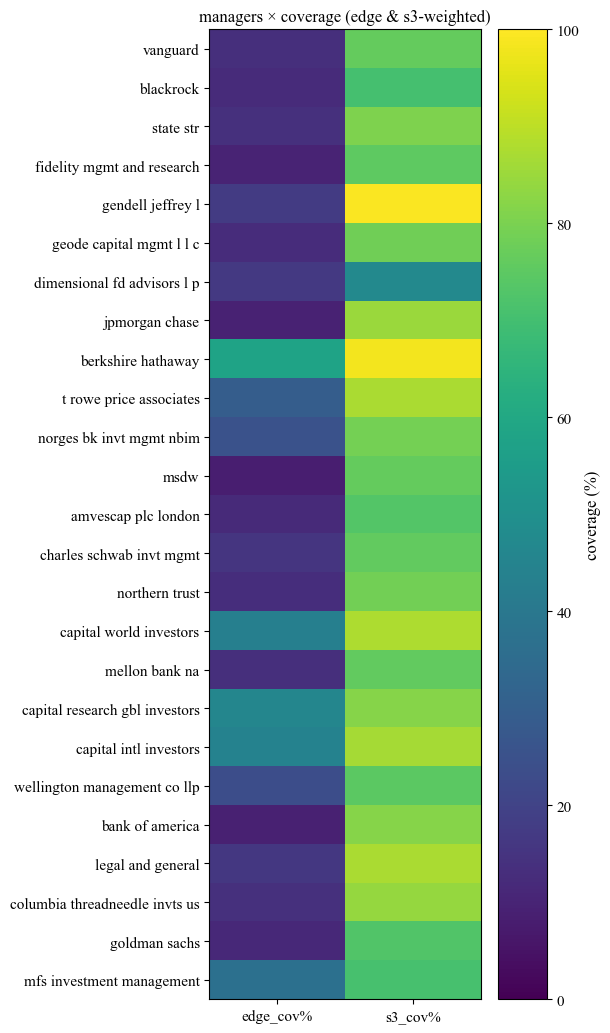

✅ saved fig_cov_heatmap_managers.png
📄 saved coverage_by_manager_TOP.csv


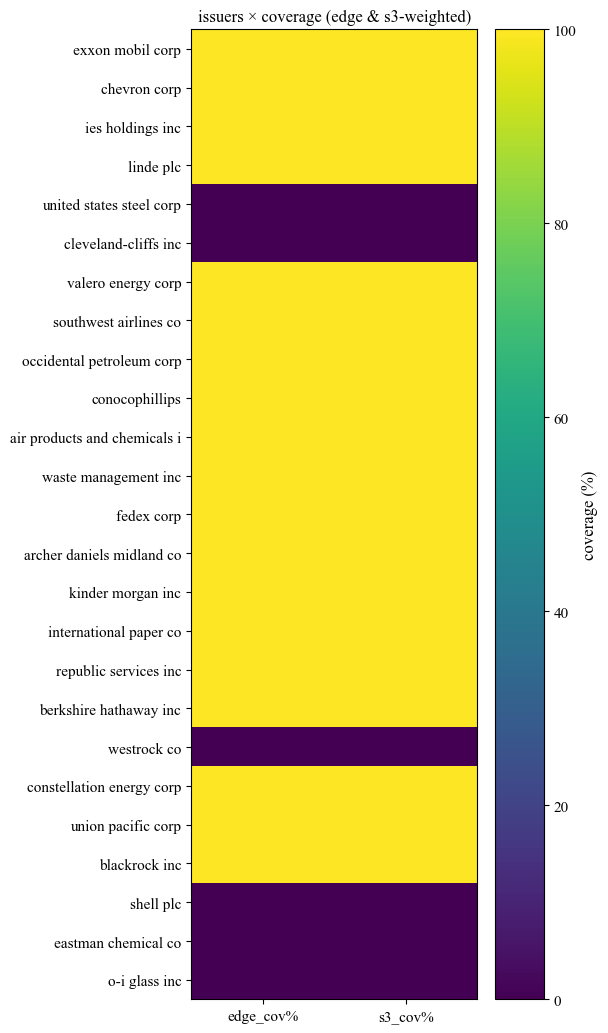

✅ saved fig_cov_heatmap_issuers.png
📄 saved coverage_by_issuer_TOP.csv


In [3]:
# ============================================
# Heatmaps of coverage — managers & issuers
# Reads: lseg_network_with_esg.csv
# Saves:
#   fig_cov_heatmap_managers.png
#   fig_cov_heatmap_issuers.png
# ============================================

import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

DFILE = "lseg_network_with_esg.csv"
TOP_N = 25  # how many rows to show (by size)

# ---------- style ----------
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

def _find_col(df, preferred=None, contains=None, regex=None):
    cols = list(df.columns)
    if preferred:
        lut = {c.lower(): c for c in cols}
        for p in preferred:
            if p and p.lower() in lut:
                return lut[p.lower()]
    if contains:
        toks = [t.lower() for t in contains]
        for c in cols:
            if any(t in c.lower() for t in toks):
                return c
    if regex:
        r = re.compile(regex, flags=re.I)
        for c in cols:
            if r.search(c): return c
    return None

def _detect_weight(df):
    pats = [r"financed.*(scope\s*3|s3)", r"financed_emissions_tco2", r"__financed_s3_abs__", r"\bfe(_edge)?\b", r"\bflow\b", r"\bw\b"]
    for pat in pats:
        for c in df.columns:
            if re.search(pat, c, flags=re.I):
                return c
    return None  # fall back to edge-count only

def _coverage_by(df, group_col, weight_col, has_esg_mask):
    base = df.groupby(group_col, dropna=False).size().rename("edges")
    with_esg = df.loc[has_esg_mask].groupby(group_col, dropna=False).size().rename("edges_esg")
    out = pd.concat([base, with_esg], axis=1).fillna(0)
    out["edge_cov%"] = 100 * out["edges_esg"] / out["edges"].replace(0, np.nan)

    if weight_col:
        tot  = df.groupby(group_col, dropna=False)[weight_col].sum(min_count=1).rename("s3_total")
        wmet = df.loc[has_esg_mask].groupby(group_col, dropna=False)[weight_col].sum(min_count=1).rename("s3_esg")
        out = pd.concat([out, tot, wmet], axis=1).fillna(0)
        out["s3_cov%"] = 100 * out["s3_esg"] / out["s3_total"].replace(0, np.nan)
    else:
        out["s3_total"] = 0.0
        out["s3_cov%"] = np.nan
    return out

def _heatmap(df_cov, title, fname):
    # columns to plot (ensure both exist; if s3_cov% is all NaN, just plot edge_cov%)
    cols = ["edge_cov%", "s3_cov%"] if df_cov["s3_cov%"].notna().any() else ["edge_cov%"]
    H = df_cov[cols].to_numpy(float)

    # dynamic figure size
    n_rows, n_cols = H.shape
    fig_h = max(6, 0.42 * n_rows)
    fig_w = max(6, 2.0 + 1.5 * n_cols)

    plt.figure(figsize=(fig_w, fig_h))
    im = plt.imshow(H, aspect="auto", vmin=0, vmax=100)
    cbar = plt.colorbar(im)
    cbar.set_label("coverage (%)")

    ax = plt.gca()
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([str(i).lower() for i in df_cov.index])
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([c.lower() for c in cols], rotation=0)

    plt.title(title)
    plt.tight_layout()
    plt.savefig(fname, dpi=180)
    plt.show()
    print(f"✅ saved {fname}")

# ---------- load ----------
df = pd.read_csv(DFILE, low_memory=False)

mgr_col = _find_col(df, preferred=["_manager_key","manager","mgrname","owner","fund"], contains=["manager","owner","fund"])
iss_col = _find_col(df, preferred=["_issuer_norm","stock","issuer","company"], contains=["stock","issuer","company"])
esg_join_key = _find_col(df, preferred=["_company_norm","esg_company"])
w_col = _detect_weight(df)

if w_col:
    df["_wS3_"] = pd.to_numeric(df[w_col], errors="coerce").clip(lower=0).fillna(0.0)
    w_col = "_wS3_"

has_esg = df[esg_join_key].notna() if esg_join_key else pd.Series(False, index=df.index)

# ---------- MANAGERS heatmap ----------
if mgr_col:
    cov_mgr = _coverage_by(df, mgr_col, w_col, has_esg)
    # order by size (s3_total if available, else edges) and take top N
    ord_mgr = cov_mgr.sort_values(["s3_total","edges"], ascending=[False, False]).head(TOP_N)
    _heatmap(ord_mgr, "managers × coverage (edge & s3-weighted)", "fig_cov_heatmap_managers.png")
    ord_mgr.to_csv("coverage_by_manager_TOP.csv")
    print("📄 saved coverage_by_manager_TOP.csv")

# ---------- ISSUERS heatmap ----------
if iss_col:
    cov_iss = _coverage_by(df, iss_col, w_col, has_esg)
    ord_iss = cov_iss.sort_values(["s3_total","edges"], ascending=[False, False]).head(TOP_N)
    _heatmap(ord_iss, "issuers × coverage (edge & s3-weighted)", "fig_cov_heatmap_issuers.png")
    ord_iss.to_csv("coverage_by_issuer_TOP.csv")
    print("📄 saved coverage_by_issuer_TOP.csv")
